<a href="https://colab.research.google.com/github/orangegreen212/Revenue-Analytics-E-commerce-Growth-Analysis/blob/main/Revenue_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Revenue Analytics: E-commerce Growth Analysis

**Stack:** Python · DuckDB · SQL · pandas · scikit-learn · seaborn

**Data:** 47,000+ transactions · 5,000+ customers · April 2024 – October 2025 · 10 countries

**Business context:** B2B/B2C software reseller — Microsoft, Adobe, Salesforce, Notion, Tableau and others. Annual subscriptions, monthly subscriptions, one-time licenses. Channels: Website, Affiliate, Paid Search, Organic, Social, Retail Media, Email. Markets: US, UK, Canada, Australia, Germany, France, Spain, Netherlands, Philippines, Brazil.

**Goal:** Understand where revenue comes from, where it leaks, which customers are worth acquiring, and what the business should do next.


In [1]:
!pip install -q jupysql duckdb-engine
!pip install -q prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.2/240.2 kB 5.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%load_ext sql
%sql duckdb://

Connecting to 'duckdb://'

In [5]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns


file_path = '/content/drive/MyDrive/Colab Notebooks/Revenue Analytycs/DataDNA Dataset Challenge - E-commerce Dataset - November 2025.xlsx'
df_events = pd.read_excel(file_path, sheet_name='Events')
df_products = pd.read_excel(file_path, sheet_name='Products')
df_customers = pd.read_excel(file_path, sheet_name='Customers')

In [6]:
df_events.head(2)

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,36.7,NaN,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,19.7,NaN,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN


In [7]:
num_duplicates = df_events.duplicated().sum()
print(f"Duplications: {num_duplicates}")

if num_duplicates > 0:
    df_events = df_events.drop_duplicates()
    print("Duplications removed.")

Duplications: 0


In [8]:
query = """

    SELECT DISTINCT * FROM df_events

"""
df_cleaned = duckdb.sql(query).df()

df_cleaned.head(2)

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,None,Partner,...,19.0,None,0.0,0.0,190.0,1.0,190.0,False,NaT,None
1,E3F98CFBAF5C,order,2025-03-18 12:36:16,CUST0001294,PROD0026,United States,39.8283,-98.5795,None,Website,...,289.0,None,0.0,0.0,7225.0,1.0,7225.0,False,NaT,None


In [9]:
subset_cols = ['customer_id', 'event_date', 'net_revenue_usd']
tricky_dups = df_events.duplicated(subset=subset_cols).sum()

print(f"Duplications by client/date/revenue: {tricky_dups}")

Duplications by client/date/revenue: 0


In [10]:
df_products.head(2)

,product_id,product_name,category,is_subscription,billing_cycle,base_price_usd,first_release_date,vendor,resale_model,brand_safe_name,product_name_orig,base_price_usd_orig,base_key,product_version
0,PROD0001,Microsoft 365 Business Standard Monthly,Productivity Suite,True,Monthly,49.0,2023-11-24,Microsoft,Direct resale,Office Suite 365 Business Standard Monthly,Microsoft 365 Business Standard Monthly,49.0,microsoft 365 business standard,v3.0
1,PROD0002,Microsoft 365 Business Standard Annual,Productivity Suite,True,Annual,499.0,2023-02-27,Microsoft,Direct resale,Office Suite 365 Business Standard Annual,Microsoft 365 Business Standard Annual,499.0,microsoft 365 business standard,v3.0


In [11]:
num_duplicates = df_products.duplicated().sum()
print(f"Duplications: {num_duplicates}")

if num_duplicates > 0:
    df_products = df_products.drop_duplicates()
    print("Duplications removed.")

Duplications: 0


In [12]:
df_customers.head(2)

,customer_id,signup_date,region,currency_preference,segment,acquisition_channel,age_band,country,country_latitude,country_longitude
0,CUST0000001,2025-07-28 15:21:00,EU,GBP,Consumer,Affiliate,55+,United Kingdom,55.3781,-3.4360
1,CUST0000002,2024-09-01 00:03:00,APAC,AUD,Consumer,Organic,55+,Australia,-25.2744,133.7751


In [ ]:
num_duplicates = df_customers.duplicated().sum()
print(f"Duplications: {num_duplicates}")

if num_duplicates > 0:
    df_customers = df_customers.drop_duplicates()
    print("Duplications removed.")

Duplications: 0


##1.Monthly Revenue

In [13]:
query = """
SELECT
    DATE_TRUNC('month', CAST(event_date AS DATE)) AS month,
    SUM(net_revenue_usd) AS gross_revenue,
    SUM(CASE WHEN is_refunded = TRUE THEN net_revenue_usd ELSE 0 END) AS refund_losses,
    SUM(CASE WHEN is_refunded = FALSE THEN net_revenue_usd ELSE 0 END) AS net_revenue
FROM 'df_events'
GROUP BY month
ORDER BY month;
"""

df_monthly = duckdb.sql(query).df()

df_monthly.head()

,month,gross_revenue,refund_losses,net_revenue
0,2024-04-01,500500.90,12983.89,487517.01
1,2024-05-01,1718475.32,29988.15,1688487.17
2,2024-06-01,1787772.57,47338.83,1740433.74
3,2024-07-01,1764479.90,36844.07,1727635.83
4,2024-08-01,1749057.23,24459.41,1724597.82


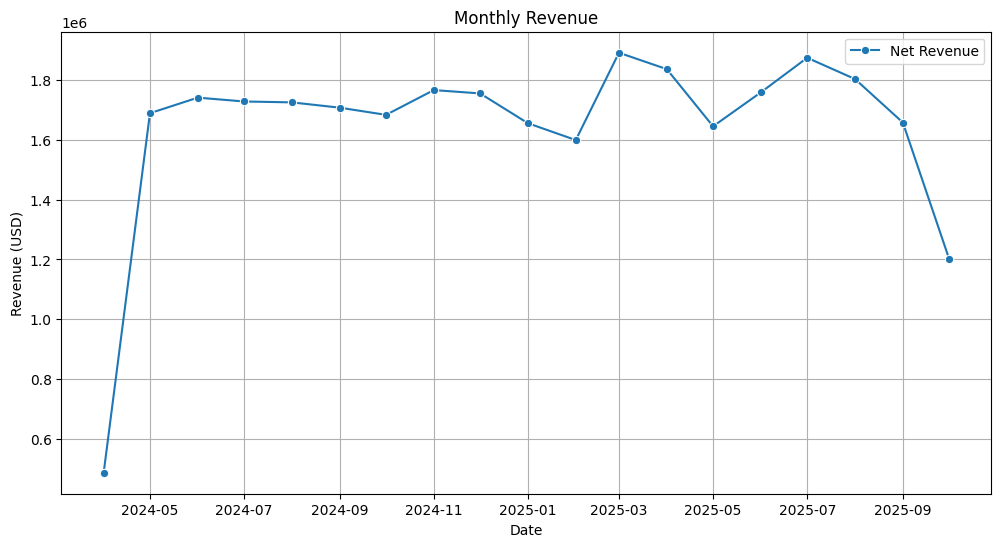

In [14]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_monthly, x='month', y='net_revenue', label='Net Revenue', marker='o')

plt.title('Monthly Revenue')
plt.ylabel('Revenue (USD)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

**Insight:** Net revenue:  487K usd (Apr 2024) → 1.69M usd (May 2024) → straight  ~1.65–1.75M usd for 14 months → dropped to 1.20M usd (Oct 2025). Refund losses: 12.9K usd (Apr) → peak 47.3K usd (Jun 2024) → stabilized 25–40K/month. The 14-month plateau is not seasonal — it is a structural growth stall. All three revenue drivers stopped moving simultaneously.


##2.Top 5 Countries

In [15]:
query = """
SELECT
    country,
    SUM(net_revenue_usd) as total_revenue
FROM df_events
GROUP BY country
ORDER BY total_revenue DESC;
"""

top_countries = duckdb.sql(query).df()
top_countries.head(5)

,country,total_revenue
0,United States,8576828.53
1,United Kingdom,5035009.06
2,Canada,3194218.95
3,Australia,3192846.14
4,Germany,2685114.73


**Insight:** US =  8.58M usd (27% of total), UK = 5.04M usd, Canada = 3.19M usd, Australia = 3.19M usd, Germany = 2.69M usd. Raw revenue hides efficiency is market size does not equal monetization potential. See Section 16 (revenue per user) for the normalized view that reveals real expansion targets.


##3.Order (new sale) or invoice (renewal/billing)

In [16]:
query = """
SELECT
    event_type,
    DATE_TRUNC('month', CAST(event_date AS DATE)) AS month,
    SUM(net_revenue_usd) as total_revenue
FROM df_events
GROUP BY month, event_type
ORDER BY month ASC;
"""

new_renew = duckdb.sql(query).df()
new_renew.head(5)

,event_type,month,total_revenue
0,invoice,2024-04-01,128587.99
1,order,2024-04-01,371912.91
2,order,2024-05-01,1201592.57
3,invoice,2024-05-01,516882.75
4,order,2024-06-01,1274739.00


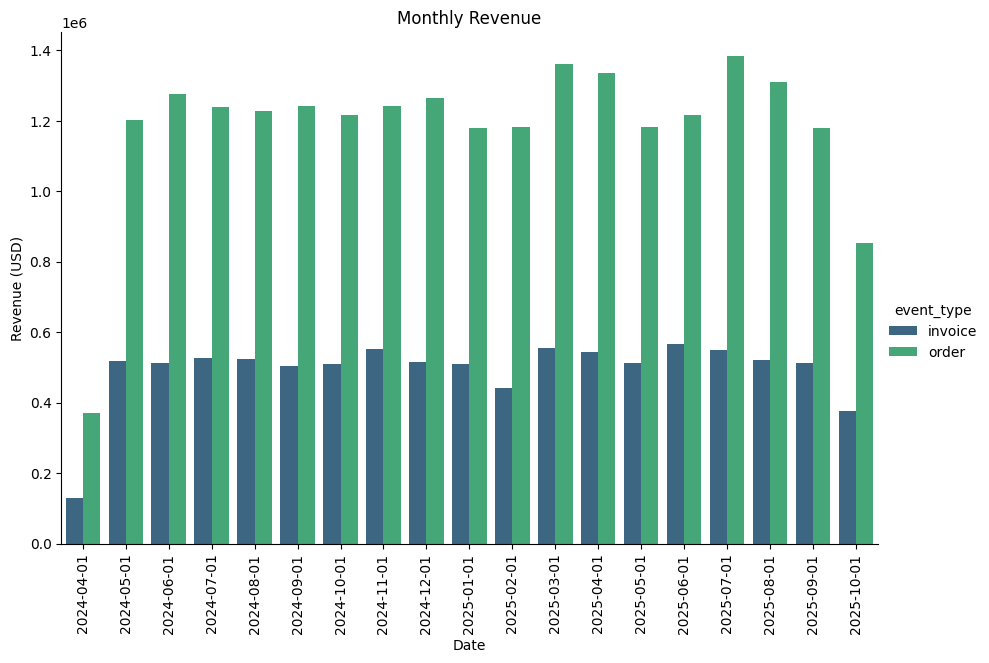

In [17]:
g = sns.catplot(data=new_renew, kind="bar", x='month', y='total_revenue',
            hue='event_type',height=6,aspect=1.5, palette='viridis')

plt.title('Monthly Revenue')
plt.ylabel('Revenue (USD)')
plt.xlabel('Date')
g.set_xticklabels(rotation=90)
plt.show()

**Insight:** April 2024  orders 371,913 usd (76%), invoices 128,588 usd (24%). Invoice share grew steadily through 2024. Growing invoice (renewal) revenue = the customer base is compounding. If invoices start falling month-over-month, the business is eroding from inside is 6–12 months before total revenue shows it, because annual contracts mask the decline.


##4 **AOV (Average Order Value).**

In [18]:
query = """
SELECT
    channel,
    SUM(net_revenue_usd) / COUNT(DISTINCT event_id) as aov
FROM 'df_events'
WHERE is_refunded = FALSE
GROUP BY channel
ORDER BY aov DESC;
"""

aov_by_channel = duckdb.sql(query).df()

aov_by_channel.head()

,channel,aov
0,Marketplace,689.580293
1,Website,670.076927
2,Partner,663.071404
3,Direct Sales,649.581144
4,Reseller,647.019123


**Insight:** AOV range across all channels: 647–690 usd is a 42 usd spread on ~660 usd average. Channels are NOT differentiated by transaction size. Any budget or channel decision made on the basis of AOV alone is based on noise, not signal.


##5 **ARPPU (Average Revenue Per Paying User)**

In [19]:
query = """
SELECT
    channel,
    SUM(net_revenue_usd) / COUNT(DISTINCT customer_id) as arpu
FROM 'df_events'
WHERE is_refunded = FALSE
GROUP BY channel
ORDER BY arpu DESC;
"""

arpu_by_channel = duckdb.sql(query).df()

arpu_by_channel.head()

,channel,arpu
0,Website,3558.676861
1,Direct Sales,1702.509749
2,Reseller,1330.977085
3,Marketplace,1169.256188
4,Partner,1131.928887


**Insight:** Website ARPU = 3,558 usd. Direct Sales = 1,702 usd. Reseller = 1,330 usd. Marketplace = 1,169 usd. Partner = 1,131 usd. Website customers generate 3.1x more revenue per head than Partner not because they spend more per transaction, but because they come back more often and stay longer. Why ARPU can grow while the business is dying: if low-ARPU customers churn first and only high-ARPU customers remain, average ARPU rises, but total revenue falls.

##6 Revenue by Category

In [20]:
query = """
SELECT
    p.category,
    SUM(e.net_revenue_usd) as total_revenue
FROM 'df_events' as e
JOIN 'df_products' as p
ON e.product_id = p.product_id
GROUP BY p.category
ORDER BY total_revenue DESC;
"""

revenue_by_category = duckdb.sql(query).df()

revenue_by_category.head()

,category,total_revenue
0,Developer Tools,4818713.34
1,Design,4169043.53
2,AI Tools,3345712.64
3,AI Productivity,3011704.72
4,Analytics,3005445.78


**Insight:** Developer Tools = 4.82M usd, Design = 4.17M usd, AI Tools = 3.35M usd. Top 3 categories = ~38% of total revenue. This concentration means a pricing change from Microsoft or Adobe in resale terms could move the entire business P&L in one quarter.


##7 Revenue by subscriptions

In [21]:
query = """
SELECT
    p.billing_cycle,
    SUM(e.net_revenue_usd) as total_revenue,
    SUM(e.net_revenue_usd)/COUNT(e.event_id) as aov_per_event
FROM 'df_events' as e
JOIN 'df_products' as p
ON e.product_id = p.product_id
GROUP BY p.billing_cycle
ORDER BY total_revenue DESC;
"""

diff_subscriptions = duckdb.sql(query).df()

diff_subscriptions .head()

,billing_cycle,total_revenue,aov_per_event
0,Annual,28106790.05,1208.270572
1,Monthly,2786335.25,117.087669
2,One-time,939156.18,998.040574


**Insight:** Annual = 28.1M usd (AOV 1,208 usd), Monthly = 2.8M usd (AOV 117 usd), One-time = 939K. Annual subscriptions = 88% of total revenue. This creates renewal cliff risk: a bad renewal month is invisible in revenue data for up to 12 months because the customer is already paid. Track renewal health with leading indicators, not lagging revenue.


##8 Retention Rate and cohorts

In [22]:
query = """
WITH first_purchase AS
(
  SELECT
    customer_id,
     MIN(DATE_TRUNC('month', event_date)) as cohort_month,
FROM 'df_events'
GROUP BY customer_id),
activity as (
  SELECT
DISTINCT customer_id,
     DATE_TRUNC('month', event_date) as activity_month,
FROM 'df_events',
)
SELECT
f.cohort_month,
a.activity_month,
COUNT(DISTINCT a.customer_id) as activity_users
FROM first_purchase as f
JOIN activity as a
ON f.customer_id = a.customer_id
GROUP BY 1,2
ORDER BY  1,2;
"""

retention_cohorts = duckdb.sql(query).df()

retention_cohorts

,cohort_month,activity_month,activity_users
0,2024-04-01,2024-04-01,695
1,2024-04-01,2024-05-01,352
2,2024-04-01,2024-06-01,326
3,2024-04-01,2024-07-01,365
4,2024-04-01,2024-08-01,361
...,...,...,...
161,2025-05-01,2025-05-01,3
162,2025-05-01,2025-06-01,1
163,2025-05-01,2025-08-01,1
164,2025-05-01,2025-09-01,2


In [23]:
retention_cohorts['cohort_month'] = pd.to_datetime(retention_cohorts['cohort_month'])
retention_cohorts['activity_month'] = pd.to_datetime(retention_cohorts['activity_month'])

retention_cohorts['month_number'] = ((retention_cohorts['activity_month'].dt.year - retention_cohorts['cohort_month'].dt.year) * 12 +
                                     (retention_cohorts['activity_month'].dt.month - retention_cohorts['cohort_month'].dt.month))

cohort_pivot = retention_cohorts.pivot(index='cohort_month', columns='month_number', values='activity_users')

cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix.index = retention_matrix.index.strftime('%Y-%m')

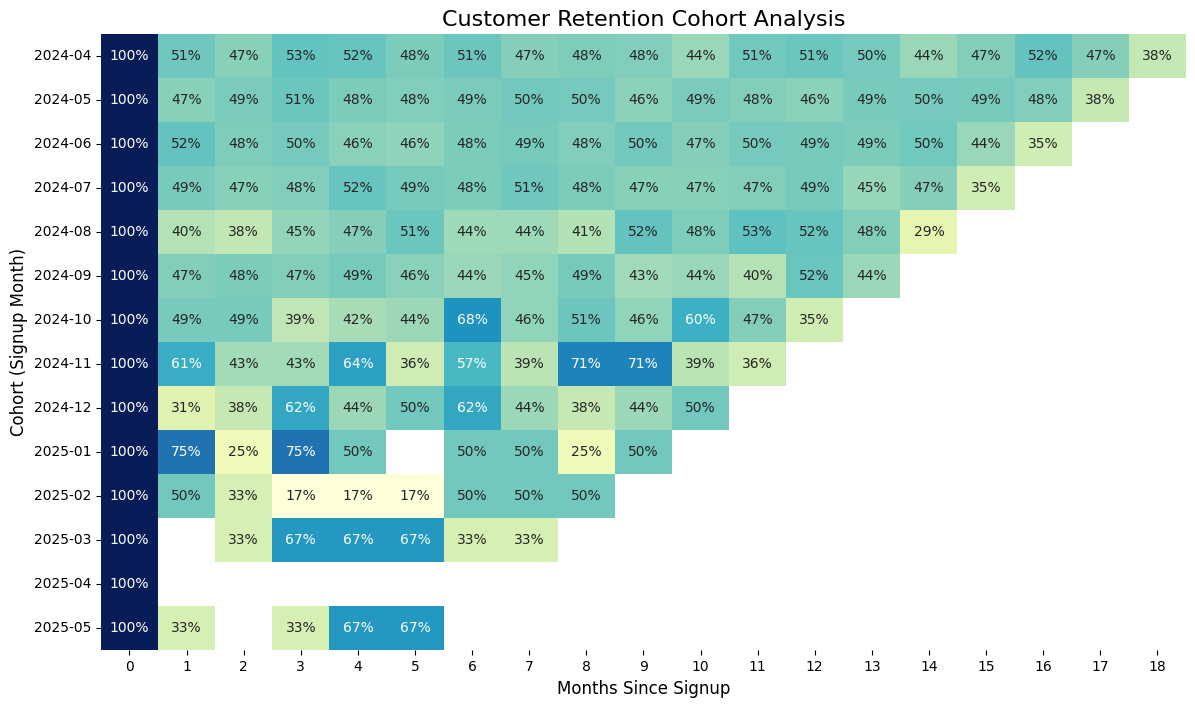

In [24]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True,fmt='.0%',
            cmap='YlGnBu',
            cbar=False
)

plt.title('Customer Retention Cohort Analysis', fontsize=16)
plt.ylabel('Cohort (Signup Month)', fontsize=12)
plt.xlabel('Months Since Signup', fontsize=12)
plt.show()

**Insight:** April 2024 cohort: 695 signups → 352 Month 1 (50.6%) → 326 Month 2 (46.9%) → stabilizes  50–55% from Month 3. Nearly 49% of new customers do not return in the first 30 days. Customers who survive 60 days tend to stay. The problem is activation is not product, not price. Improving Month 1 retention from 51% to 65% (220 extra retained customers per monthly cohort) at 3,558 usd avg ARPU = 783K usd additional annual revenue per cohort with zero additional acquisition spend.


##9.CLV / LTV

In [25]:
query = """
SELECT
    customer_id,
    SUM(net_revenue_usd) as total_revenue,
    COUNT(event_id) as total_orders,
    DATE_DIFF('month',MIN(event_date), MAX(event_date))+1 as total_month_period
FROM 'df_events'
WHERE is_refunded ='FALSE'
GROUP BY customer_id;
"""

ltv = duckdb.sql(query).df()

ltv.head()

,customer_id,total_revenue,total_orders,total_month_period
0,CUST0001105,12714.79,13,17
1,CUST0001294,12289.70,12,11
2,CUST0000851,3763.94,11,17
3,CUST0002670,12762.28,16,18
4,CUST0003838,7209.59,9,14


In [26]:
query = """
SELECT
    c.acquisition_channel,
    c.region,
    c.segment,
    COUNT(DISTINCT e.customer_id) as total_customers,
    SUM(e.net_revenue_usd) / COUNT(DISTINCT e.customer_id) as avg_ltv
FROM df_events e
JOIN df_customers c ON e.customer_id = c.customer_id
WHERE e.is_refunded = FALSE
GROUP BY 1, 2, 3
ORDER BY avg_ltv DESC;
"""

ltv_segments = duckdb.sql(query).df()

ltv_segments

,acquisition_channel,region,segment,total_customers,avg_ltv
0,Affiliate,LATAM,SOHO,2,21451.180000
1,Organic,LATAM,Enterprise,1,18177.680000
2,Retail Media,LATAM,Enterprise,1,14617.230000
3,Email,LATAM,SMB,6,12561.326667
4,Affiliate,EU,Enterprise,5,11980.592000
...,...,...,...,...,...
86,Social,APAC,Enterprise,2,5622.300000
87,Email,None,SMB,34,5602.599412
88,Retail Media,APAC,SOHO,4,4865.770000
89,Affiliate,LATAM,Consumer,11,4328.558182


<Figure size 600x800 with 0 Axes>

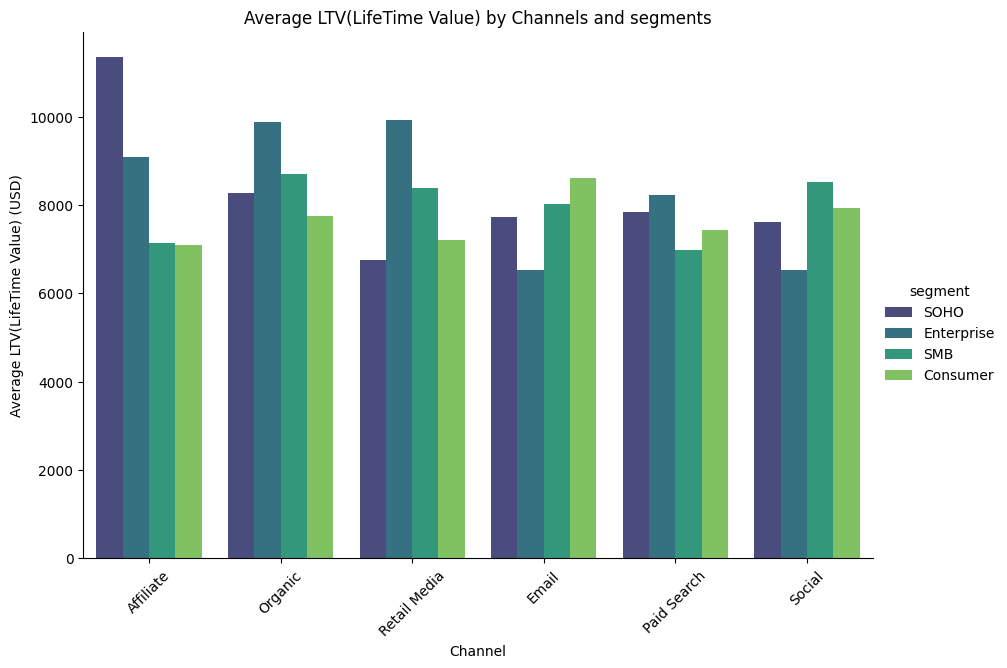

In [29]:
plt.figure(figsize=(6, 8))

g = sns.catplot(data=ltv_segments, kind="bar", x='acquisition_channel', y='avg_ltv',
            hue='segment',height=6,aspect=1.5, palette='viridis',errorbar=None)

plt.title('Average LTV(LifeTime Value) by Channels and segments')
plt.ylabel('Average LTV(LifeTime Value) (USD)')
plt.xlabel('Channel')
g.set_xticklabels(rotation=45)
plt.show()

**Insight — top LTV combinations:**
- Affiliate / LATAM / SOHO: 21,451 usd avg LTV
- Organic / LATAM / Enterprise: 18,178 usd
- Retail Media / LATAM / Enterprise: 14,617 usd
- Affiliate / EU / Enterprise: 11,981 usd

Affiliate and Organic appear in the top combinations. Paid Search and Social do not appear in the top 10. Biggest opportunity: Affiliate is underfunded relative to Paid Search in most portfolios — the LTV data says this allocation is backwards. Why revenue can grow and still be a problem: if Paid Search and Social grow in share while Affiliate and Organic shrink, short-term revenue rises but customer quality deteriorates — churn spikes 6 months later.


##10.Churn rate

In [30]:
query = """
WITH last_date AS
(
  SELECT
    customer_id,
     MAX( event_date) as last_purchase,
FROM 'df_events'
GROUP BY customer_id),
churned as (
  SELECT customer_id,
  CASE WHEN last_purchase< (SELECT MAX(event_date) - INTERVAL '60 days' from 'df_events') THEN 1 ELSE 0 END as is_churned

FROM last_date,
)
SELECT
SUM(is_churned)/COUNT(*) as churn_rate
FROM churned;
"""

churn_rate = duckdb.sql(query).df()

churn_rate

,churn_rate
0,0.267


In [31]:
query = """
WITH LastActivity AS (
    SELECT
        customer_id,
        MAX(event_date) as last_seen,
        (SELECT MAX(event_date) FROM df_events) as current_date
    FROM df_events
    GROUP BY customer_id
),
CustomerStatus AS (
    SELECT
        c.acquisition_channel as channel,
        c.segment,
        l.customer_id,
        CASE WHEN l.last_seen < (l.current_date - INTERVAL '60 days')
             THEN 1 ELSE 0 END as is_churned
    FROM LastActivity l
    JOIN df_customers c ON l.customer_id = c.customer_id
)
SELECT
    channel,
    segment,
    COUNT(*) as total_customers,
    SUM(is_churned) as churned_customers,
    ROUND(SUM(is_churned)::float / COUNT(*), 3) as churn_rate
FROM CustomerStatus
GROUP BY 1, 2
ORDER BY churn_rate DESC;
"""

churn_rate_segments = duckdb.sql(query).df()

churn_rate_segments.head()

,channel,segment,total_customers,churned_customers,churn_rate
0,Paid Search,Enterprise,21,10.0,0.476
1,Social,Enterprise,17,8.0,0.471
2,Affiliate,SMB,66,26.0,0.394
3,Affiliate,SOHO,83,28.0,0.337
4,Social,SOHO,137,42.0,0.307


<Figure size 600x800 with 0 Axes>

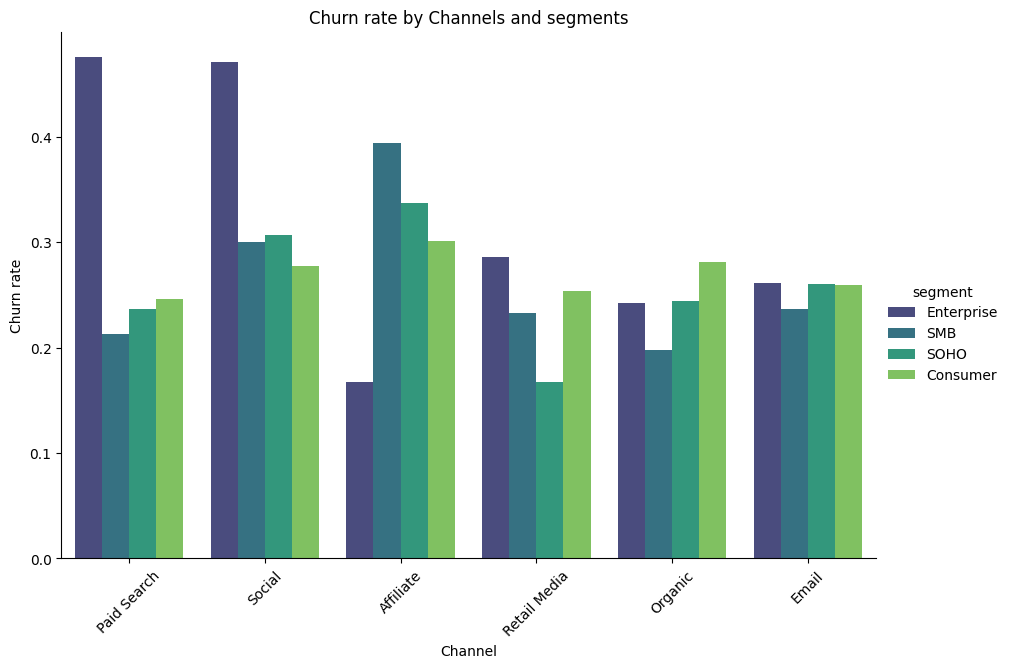

In [32]:
plt.figure(figsize=(6, 8))

g = sns.catplot(data=churn_rate_segments, kind="bar", x='channel', y='churn_rate',
            hue='segment',height=6,aspect=1.5, palette='viridis',errorbar=None)

plt.title('Churn rate by Channels and segments')
plt.ylabel('Churn rate')
plt.xlabel('Channel')
g.set_xticklabels(rotation=45)
plt.show()

**Insight:** Overall churn = 26.7%. Worst: Paid Search + Enterprise 47.6%, Social + Enterprise 47.1%. Best: Affiliate + Enterprise 16.7%, Organic + SMB 19.8%. The same Enterprise segment churns at 47.6% from Paid Search and 16.7% from Affiliate. Same product, same segment - 3x difference in churn. The problem is who these channels attract, not the product.


##11.Decomposition REVENUE - USERS - CONVERSION - AOV

In [33]:
query = """
SELECT
    DATE_TRUNC('month', event_date) AS month,
    COUNT(DISTINCT customer_id) AS unique_users,
    COUNT(DISTINCT event_id) AS total_orders,
    COUNT(DISTINCT event_id) * 1.0 / COUNT(DISTINCT customer_id) AS conversion_rate,
    SUM(net_revenue_usd) / COUNT(DISTINCT event_id) AS aov,
    SUM(net_revenue_usd) AS total_revenue
FROM df_events
WHERE is_refunded = FALSE
GROUP BY month
ORDER BY month;
"""

revenue_drivers = duckdb.sql(query).df()

revenue_drivers.head()

,month,unique_users,total_orders,conversion_rate,aov,total_revenue
0,2024-04-01,680,747,1.098529,652.633213,487517.01
1,2024-05-01,1998,2755,1.378879,612.881005,1688487.17
2,2024-06-01,1867,2564,1.373326,678.796310,1740433.74
3,2024-07-01,1994,2697,1.352558,640.576874,1727635.83
4,2024-08-01,1983,2763,1.393343,624.175831,1724597.82


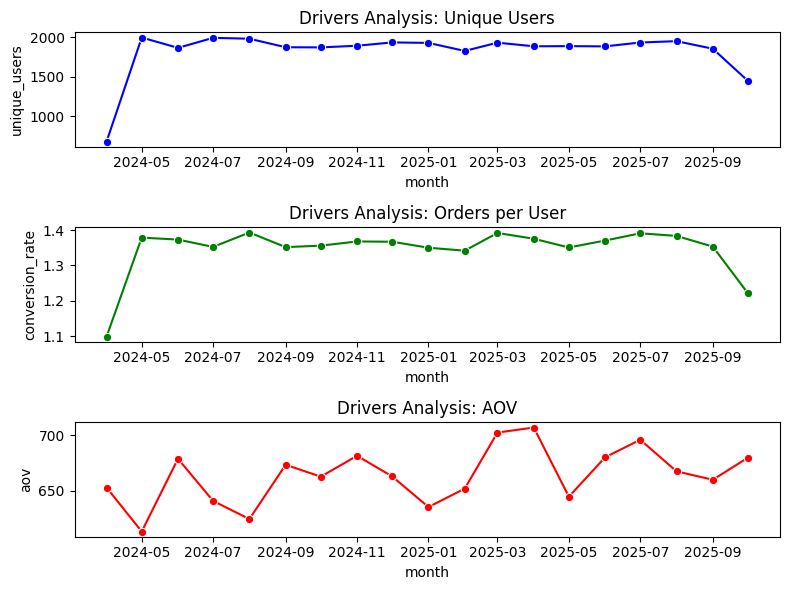

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6))

sns.lineplot(data=revenue_drivers, x='month', y='unique_users', ax=axes[0], marker='o', color='blue')
axes[0].set_title('Drivers Analysis: Unique Users')

sns.lineplot(data=revenue_drivers, x='month', y='conversion_rate', ax=axes[1], marker='o', color='green')
axes[1].set_title('Drivers Analysis: Orders per User')

sns.lineplot(data=revenue_drivers, x='month', y='aov', ax=axes[2], marker='o', color='red')
axes[2].set_title('Drivers Analysis: AOV')

plt.tight_layout()
plt.show()

**Insight — Revenue = Users × Orders/User × AOV:**

The May jump was 100% driven by user volume. AOV fell. Since June 2024 all three drivers are flat. To grow from here: more users OR higher frequency OR higher AOV is all three have been flat for 14 months. This decomposition is the diagnostic tool — when revenue moves, check which driver moved first. Each driver has a different fix.


##12.Refundig Rate

In [35]:
query = """
SELECT
    p.product_name as product_name,
    e.country,
    e.channel,
    COUNT(*) as total_orders,
    SUM(CASE WHEN is_refunded = TRUE THEN 1 ELSE 0 END) as refunded_orders,
    ROUND(SUM(CASE WHEN is_refunded = TRUE THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as refund_rate,
    SUM(CASE WHEN is_refunded = TRUE THEN net_revenue_usd ELSE 0 END) as revenue_lost
FROM df_events e
JOIN df_products p ON e.product_id = p.product_id
GROUP BY 1, 2, 3
HAVING total_orders > 10 AND refunded_orders>0
ORDER BY refund_rate DESC;
"""

refund_analysis  = duckdb.sql(query).df()

refund_analysis

,product_name,country,channel,total_orders,refunded_orders,refund_rate,revenue_lost
0,Adobe Firefly Creative AI Annual Standard,Canada,Reseller,11,2.0,18.18,5674.04
1,Notion Plus Monthly,Brazil,Website,11,2.0,18.18,241.50
2,Airtable Team Monthly,Netherlands,Website,11,2.0,18.18,690.07
3,Tableau Creator Monthly,United States,Marketplace,11,2.0,18.18,177.50
4,Power BI Pro Annual,Australia,Website,12,2.0,16.67,661.25
...,...,...,...,...,...,...,...
506,Azure AI Studio Annual Standard,United States,Website,75,1.0,1.33,316.27
507,Microsoft Copilot for Office Annual,United States,Website,76,1.0,1.32,2870.66
508,Zoom Pro Annual,United States,Website,76,1.0,1.32,134.91
509,Asana Premium Monthly,United States,Website,77,1.0,1.30,187.50


In [36]:
query = """
SELECT
    p.category as product_category,
    e.country,
    e.channel,
    COUNT(*) as total_orders,
    SUM(CASE WHEN is_refunded = TRUE THEN 1 ELSE 0 END) as refunded_orders,
    ROUND(SUM(CASE WHEN is_refunded = TRUE THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as refund_rate,
    SUM(CASE WHEN is_refunded = TRUE THEN net_revenue_usd ELSE 0 END) as revenue_lost
FROM df_events e
JOIN df_products p ON e.product_id = p.product_id
GROUP BY 1, 2, 3
HAVING total_orders > 10 AND refunded_orders>0
ORDER BY refund_rate DESC;
"""

refund_analysis_category  = duckdb.sql(query).df()

refund_analysis_category

,product_category,country,channel,total_orders,refunded_orders,refund_rate,revenue_lost
0,Monitoring,Germany,Partner,11,2.0,18.18,667.02
1,Services,United Kingdom,Direct Sales,18,3.0,16.67,4149.60
2,Support,Philippines,Marketplace,13,2.0,15.38,5727.00
3,Project Management,Spain,Partner,16,2.0,12.50,224.01
4,Add-on,Netherlands,Marketplace,30,3.0,10.00,88.80
...,...,...,...,...,...,...,...
393,Design,Philippines,Website,134,1.0,0.75,138.00
394,Design,Netherlands,Website,141,1.0,0.71,105.78
395,Productivity,United States,Partner,158,1.0,0.63,100.00
396,AI Productivity,Australia,Website,175,1.0,0.57,1238.34


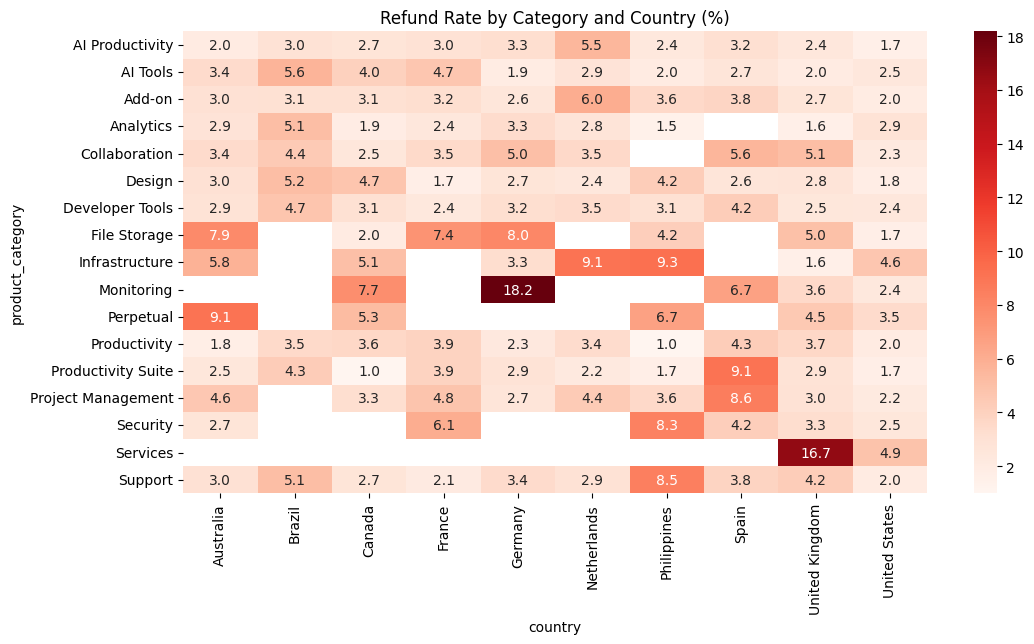

In [37]:
pivot_refund = refund_analysis_category.pivot_table(
    index='product_category',
    columns='country',
    values='refund_rate',
    aggfunc='mean'
)

# Теперь рисуем Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_refund, annot=True, cmap='Reds', fmt='.1f')
plt.title('Refund Rate by Category and Country (%)')
plt.show()

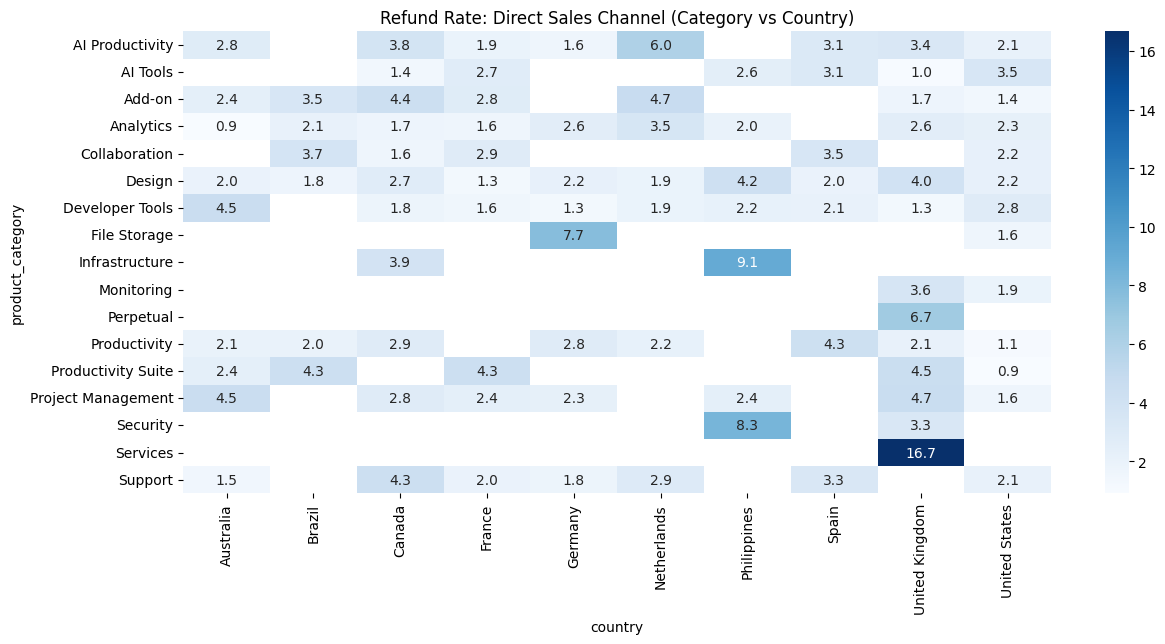

In [38]:
df_filtered = refund_analysis_category[refund_analysis_category['channel'] == 'Direct Sales']

pivot_refund = df_filtered.pivot(index='product_category', columns='country', values='refund_rate')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_refund, annot=True, cmap='Blues', fmt='.1f')
plt.title('Refund Rate: Direct Sales Channel (Category vs Country)')
plt.show()

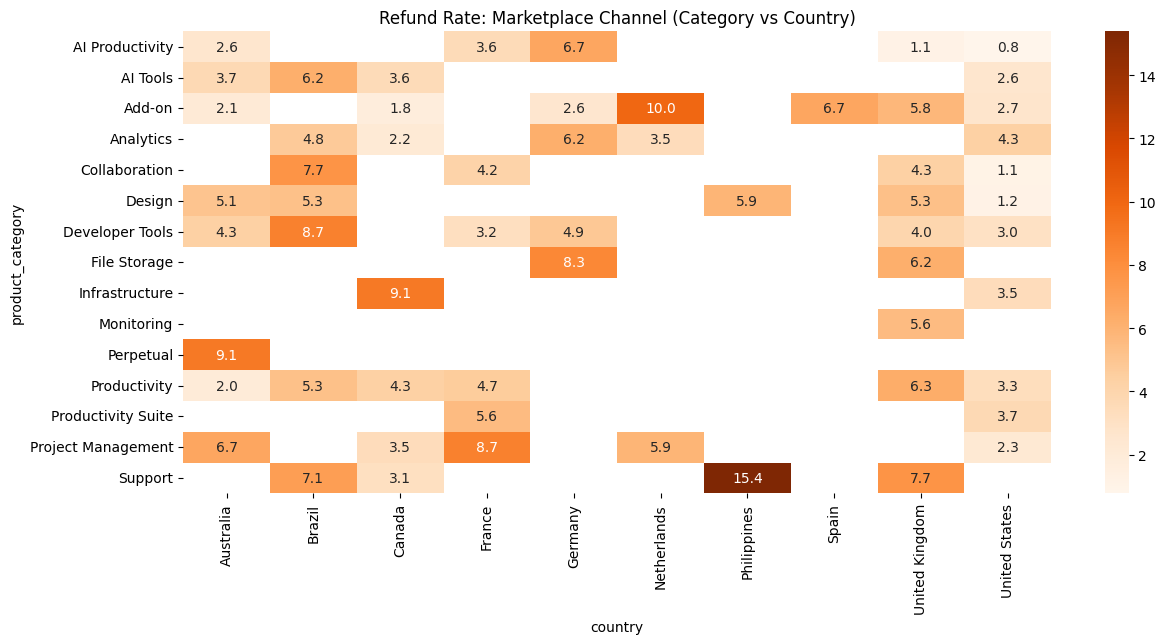

In [39]:
df_filtered = refund_analysis_category[refund_analysis_category['channel'] == 'Marketplace']

pivot_refund = df_filtered.pivot(index='product_category', columns='country', values='refund_rate')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_refund, annot=True, cmap='Oranges', fmt='.1f')
plt.title('Refund Rate: Marketplace Channel (Category vs Country)')
plt.show()

**Insight — highest revenue leaks:**
| Category | Country | Channel | Refund Rate | Revenue Lost |
|---|---|---|---|---|
| Monitoring | Germany | Partner | 18.18% | $667 |
| Services | UK | Direct Sales | 16.67% | $4,150 |
| Support | Philippines | Marketplace | 15.38% | $5,727 |
| Adobe Firefly Annual | Canada | Reseller | 18.18% | $5,674 |

Refund rates above 10% in specific combinations are not random — they signal a messaging or localization mismatch. The customer received something different from what they expected. This is recoverable: no new customers needed, just stop the loss. Fix the product listing and onboarding for these combinations. If unfixable — remove from that channel.


##13.Discount, Total Revenue and AOV


In [40]:
query = """
SELECT
    CASE WHEN discount_code IS NOT NULL AND discount_code != 'N/A'
         THEN 'With Discount' ELSE 'No Discount' END as discount_status,
    COUNT(DISTINCT event_id) as orders,
    SUM(net_revenue_usd) as total_revenue,
    SUM(net_revenue_usd) / COUNT(DISTINCT event_id) as aov,
    AVG(discount_local / (net_revenue_local + discount_local)) * 100 as avg_discount_pct
FROM df_events
WHERE is_refunded = FALSE
GROUP BY 1;
"""

discount  = duckdb.sql(query).df()

discount

,discount_status,orders,total_revenue,aov,avg_discount_pct
0,With Discount,16614,10283497.64,618.965790,10.730441
1,No Discount,30381,20913060.98,688.359862,0.000000


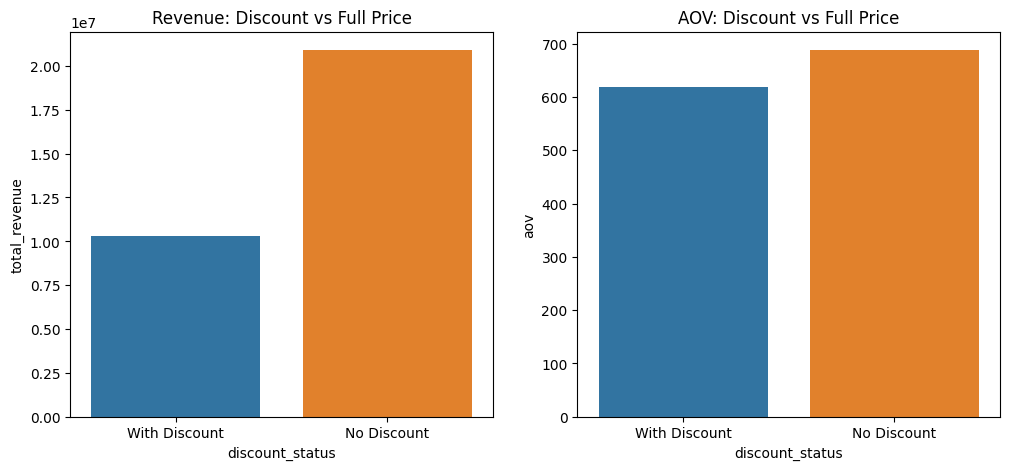

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=discount, x='discount_status', y='total_revenue', ax=axes[0], hue='discount_status')
axes[0].set_title('Revenue: Discount vs Full Price')

sns.barplot(data=discount, x='discount_status', y='aov', ax=axes[1],hue='discount_status')
axes[1].set_title('AOV: Discount vs Full Price')

plt.show()

**Insight:** No discount: 30,381 orders, AOV 688 usd, total 20.9M usd. With discount: 16,614 orders (35.4% of volume), AOV 619 usd, avg discount 10.73%, total 10.3M usd. AOV drops 10% with discounting. Unknown: whether discounted customers renew at the same rate. If they do not is the discount program is subsidizing one-time buyers at a cost of 1.1M usd in foregone revenue. Measure 90-day LTV of discounted vs full-price customers before the next campaign.


##14.Subscriptions

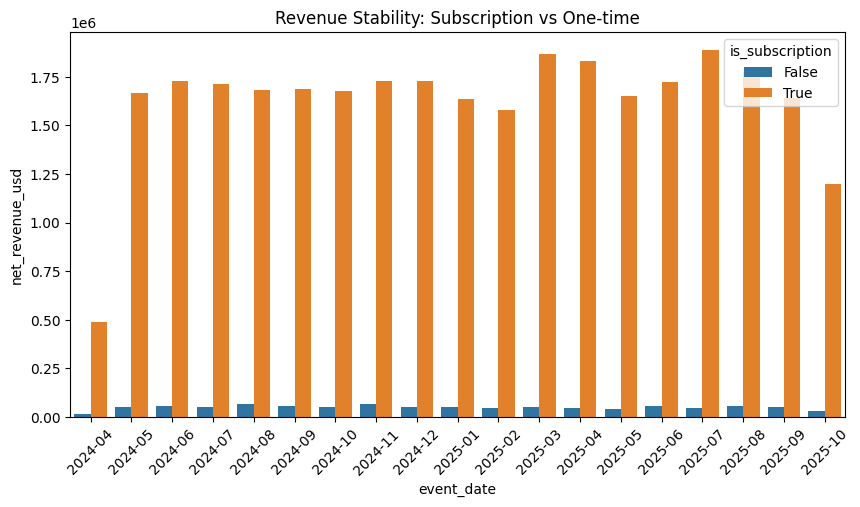

In [42]:
df_sub = df_events.merge(df_products[['product_id', 'is_subscription']], on='product_id')
sub_trend = df_sub.groupby([df_sub['event_date'].dt.to_period('M'), 'is_subscription'])['net_revenue_usd'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=sub_trend, x='event_date', y='net_revenue_usd', hue='is_subscription')
plt.title('Revenue Stability: Subscription vs One-time')
plt.xticks(rotation=45)
plt.show()

**Insight:** Subscription revenue is consistently larger than one-time and growing as a share of total. This is structurally healthy is predictable, compounding, defensible. Subscription share declining would be an early warning sign worth tracking monthly.


##15.Channel Efficiency (Revenue per User vs Conversion)

/tmp/ipykernel_6574/1178904471.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(channel_eff.conv_proxy[i], channel_eff.rev_per_user[i], channel_eff.index[i])


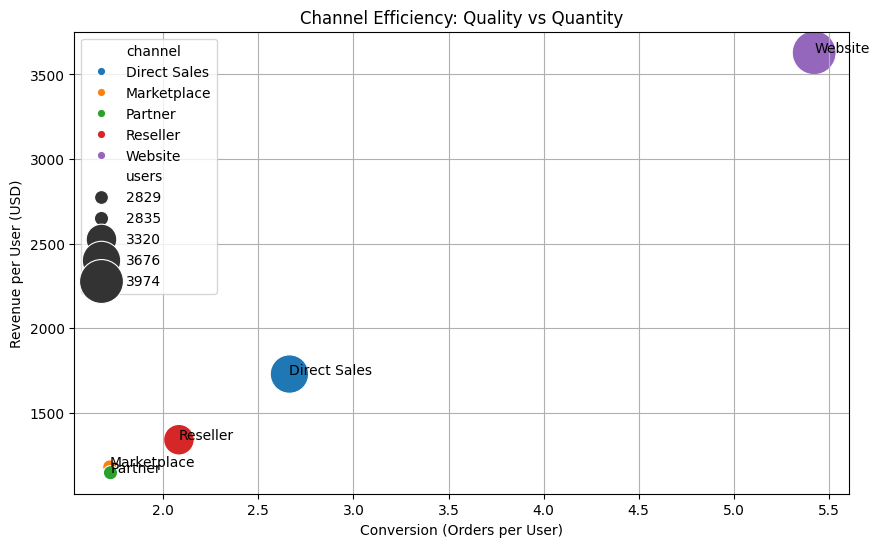

In [43]:
channel_eff = df_events.groupby('channel').agg(
    revenue_per_user=('net_revenue_usd', 'sum'),
    users=('customer_id', 'nunique'),
    orders=('event_id', 'count')
)
channel_eff['rev_per_user'] = channel_eff['revenue_per_user'] / channel_eff['users']
channel_eff['conv_proxy'] = channel_eff['orders'] / channel_eff['users']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=channel_eff, x='conv_proxy', y='rev_per_user', size='users', sizes=(100, 1000), hue=channel_eff.index)

for i in range(channel_eff.shape[0]):
    plt.text(channel_eff.conv_proxy[i], channel_eff.rev_per_user[i], channel_eff.index[i])

plt.title('Channel Efficiency: Quality vs Quantity')
plt.xlabel('Conversion (Orders per User)')
plt.ylabel('Revenue per User (USD)')
plt.grid(True)
plt.show()

**Insight:** Website: highest revenue per user (3,558 usd) + competitive order frequency = top-right of the efficiency scatter. Marketplace: highest AOV (689 usd) but revenue per user only 1,169 usd is high single transaction, no repeat. Partner and Reseller: low ARPU, low frequency. Two channels worth scaling: Website and Affiliate. Every other channel delivers lower ARPU and worse retention.


##16.Geography (Revenue per User)

/tmp/ipykernel_6574/3857107925.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_data.head(10), x='rev_per_user', y=geo_data.head(10).index, palette='magma')


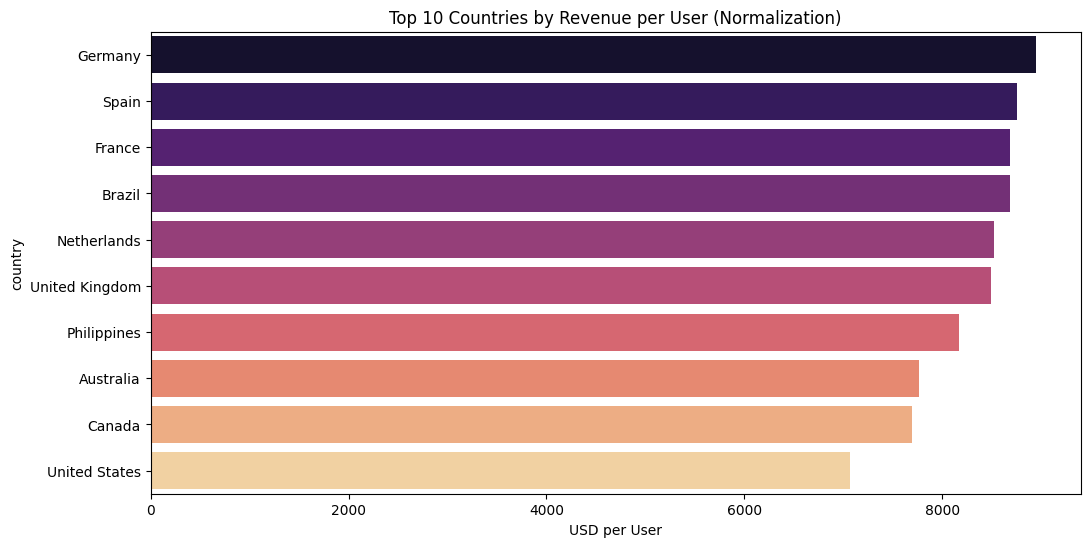

In [44]:
geo_data = df_events.groupby('country').agg(
    total_rev=('net_revenue_usd', 'sum'),
    users=('customer_id', 'nunique')
)
geo_data['rev_per_user'] = geo_data['total_rev'] / geo_data['users']
geo_data = geo_data.sort_values('rev_per_user', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=geo_data.head(10), x='rev_per_user', y=geo_data.head(10).index, palette='magma')
plt.title('Top 10 Countries by Revenue per User (Normalization)')
plt.xlabel('USD per User')
plt.show()

**Insight:** Revenue per user by country reveals markets with proven willingness to pay, independent of market size. Countries in the top-10 by revenue per user but NOT in the top-5 by total revenue = underserved high-value markets. These are the best expansion targets: demand is proven, penetration is low, no market education needed.


##17.RFM

In [45]:
now = df_events['event_date'].max() + pd.Timedelta(days=1)
rfm = df_events.groupby('customer_id').agg({
    'event_date': lambda x: (now - x.max()).days,
    'event_id': 'count',
    'net_revenue_usd': 'sum'
})

rfm['R'] = pd.qcut(rfm['event_date'], 4, labels=[4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['event_id'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M'] = pd.qcut(rfm['net_revenue_usd'], 4, labels=[1, 2, 3, 4])
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)


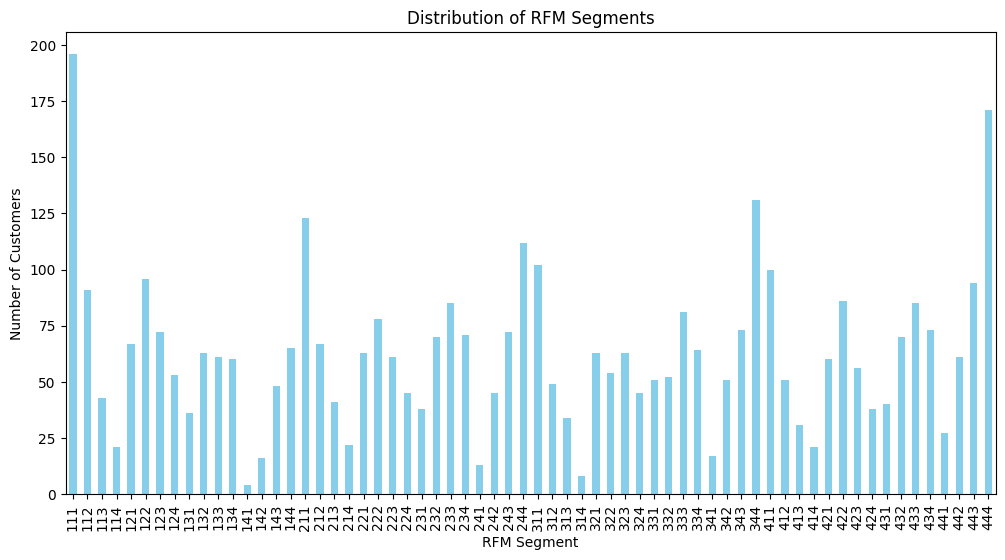

In [46]:
segment_counts = rfm['RFM_Segment'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
segment_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of RFM Segments')
plt.xlabel('RFM Segment')
plt.ylabel('Number of Customers')
plt.show()


In [47]:
rfm.head()

,event_date,event_id,net_revenue_usd,R,F,M,RFM_Segment
customer_id,,,,,,,
CUST0000001,2,11,12975.05,4,2,4,424
CUST0000002,2,14,3514.51,4,3,1,431
CUST0000003,13,10,17149.49,4,1,4,414
CUST0000004,21,17,12991.20,3,4,4,344
CUST0000005,192,10,2427.68,1,1,1,111


In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['event_date', 'event_id', 'net_revenue_usd']])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)


In [49]:
rfm.head()

,event_date,event_id,net_revenue_usd,R,F,M,RFM_Segment,cluster
customer_id,,,,,,,,
CUST0000001,2,11,12975.05,4,2,4,424,1
CUST0000002,2,14,3514.51,4,3,1,431,1
CUST0000003,13,10,17149.49,4,1,4,414,3
CUST0000004,21,17,12991.20,3,4,4,344,3
CUST0000005,192,10,2427.68,1,1,1,111,2


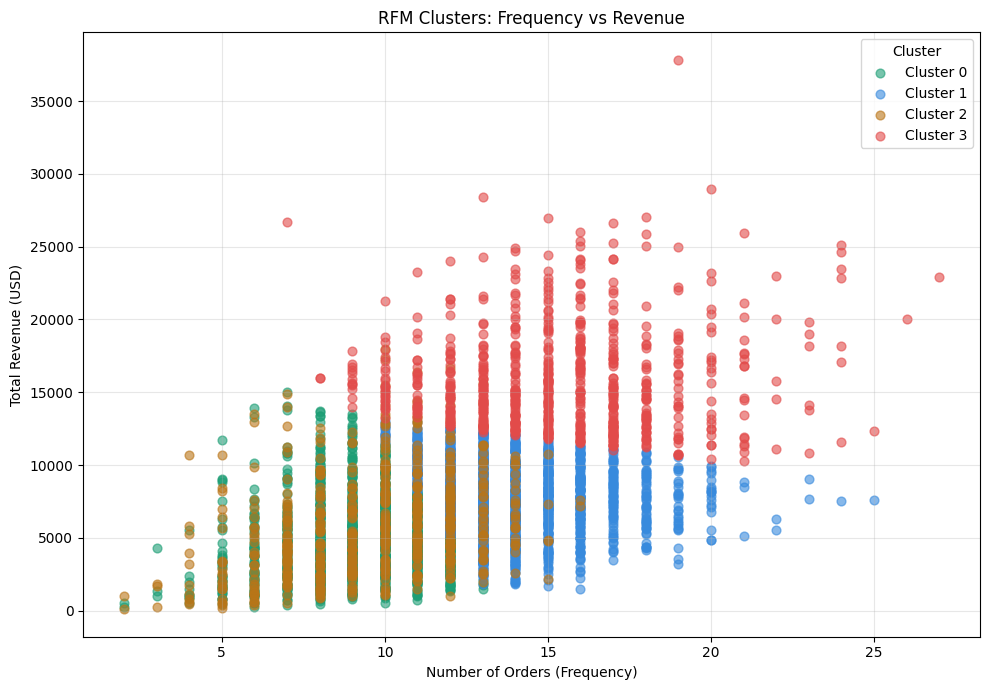

In [50]:
plt.figure(figsize=(10, 7))

colors = ['#1D9E75', '#378ADD', '#BA7517', '#E24B4A']
for cluster_id in sorted(rfm['cluster'].unique()):
    subset = rfm[rfm['cluster'] == cluster_id]
    plt.scatter(
        subset['event_id'],
        subset['net_revenue_usd'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=40
    )

plt.title('RFM Clusters: Frequency vs Revenue')
plt.xlabel('Number of Orders (Frequency)')
plt.ylabel('Total Revenue (USD)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [51]:
# Add subscription rate per customer to RFM
df_merged = df_events.merge(df_products[['product_id', 'is_subscription']], on='product_id', how='left')
subscription_rate = df_merged.groupby('customer_id')['is_subscription'].mean()
rfm = rfm.join(subscription_rate)
print(rfm.head())


             event_date  event_id  net_revenue_usd  R  F  M RFM_Segment  \
customer_id                                                               
CUST0000001           2        11         12975.05  4  2  4         424   
CUST0000002           2        14          3514.51  4  3  1         431   
CUST0000003          13        10         17149.49  4  1  4         414   
CUST0000004          21        17         12991.20  3  4  4         344   
CUST0000005         192        10          2427.68  1  1  1         111   

             cluster  is_subscription  
customer_id                            
CUST0000001        1         1.000000  
CUST0000002        1         0.928571  
CUST0000003        3         1.000000  
CUST0000004        3         0.941176  
CUST0000005        2         1.000000  


**Insight - RFM clusters (KMeans, 4 groups):**
- **Cluster 3** - 10–25 orders, 15K–38K usd revenue. Highest-value customers. Losing one costs more than losing 5 average customers.
- **Cluster 0** - moderate frequency, 8K–15K usd. Loyal mid-tier. Keep engaged.
- **Cluster 2** - moderate frequency, lower revenue. At-risk of going inactive.
- **Cluster 1** - lower revenue ceiling (~11K usd), moderate frequency. Lower engagement or single-product buyers.

Top 20% of customers by revenue are in Cluster 3. These customers need proactive retention is not reactive support after they've already decided to leave.


## 18.XGBoost: What predicts whether a customer returns?

In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 54.75%
ROC AUC: 66.49%

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.74      0.31       109
           1       0.93      0.52      0.66       691

    accuracy                           0.55       800
   macro avg       0.56      0.63      0.49       800
weighted avg       0.83      0.55      0.62       800



XGBoost tunned

In [70]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'scale_pos_weight': [ratio, ratio * 1.5]
}

xgb = XGBClassifier(random_state=42, eval_metric='auc')

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           scoring='roc_auc', cv=3, verbose=1)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC AUC: {grid_search.best_score_:.2%}")

best_model = grid_search.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(0.15816141874773795)}
Best ROC AUC: 65.98%


In [71]:
model_tunned = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=3,
    scale_pos_weight=ratio,
    random_state=42
)
model_tunned.fit(X_train, y_train)

y_pred_1 = model_tunned.predict(X_test)
y_prob_1 = model_tunned.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_1):.2%}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_1):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 50.25%
ROC AUC: 67.57%

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.74      0.31       109
           1       0.93      0.52      0.66       691

    accuracy                           0.55       800
   macro avg       0.56      0.63      0.49       800
weighted avg       0.83      0.55      0.62       800



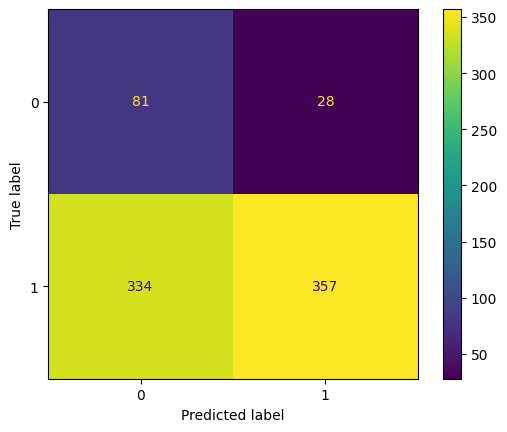

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()


ROC AUC: 66.49%


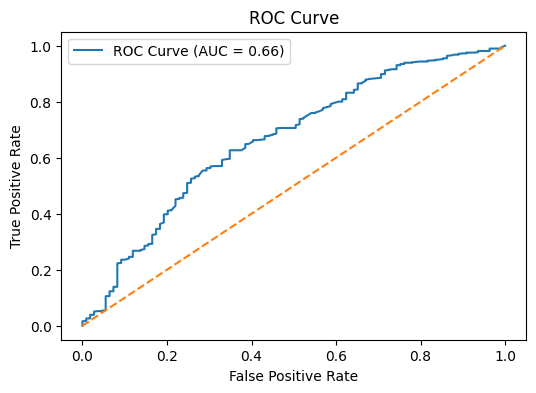

In [73]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC AUC: {roc_auc:.2%}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

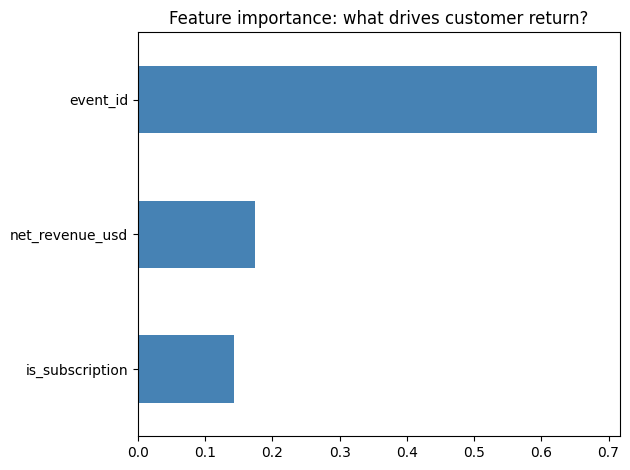

In [74]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature importance: what drives customer return?')
plt.tight_layout()
plt.show()


## 19.Time Series Forecast (Prophet)

In [55]:
from prophet import Prophet
import matplotlib.gridspec as gridspec

df_ts = df_events[df_events['is_refunded'] == False].copy()
df_ts['event_date'] = pd.to_datetime(df_ts['event_date'])
df_ts['month'] = df_ts['event_date'].dt.to_period('M').dt.to_timestamp()

top_channels = (
    df_ts.groupby('channel')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
print("Forecasting for channels:", top_channels)

monthly = (
    df_ts[df_ts['channel'].isin(top_channels)]
    .groupby(['month', 'channel'])['net_revenue_usd']
    .sum()
    .reset_index()
    .rename(columns={'month': 'ds', 'net_revenue_usd': 'y'})
)

Forecasting for channels: ['Website', 'Direct Sales', 'Reseller']


In [56]:
# ── FIT + FORECAST: 3 months ahead per channel ────────────────────────────
FORECAST_MONTHS = 3
forecasts = {}

for channel in top_channels:
    df_ch = monthly[monthly['channel'] == channel][['ds', 'y']].copy()

    m = Prophet(
        yearly_seasonality=False,   # only 18 months of data — not enough for yearly
        weekly_seasonality=False,   # monthly aggregation — no weekly signal
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.3,   # flexible — business had a big jump in May 2024
        interval_width=0.80            # 80% confidence interval
    )
    m.fit(df_ch)

    future = m.make_future_dataframe(periods=FORECAST_MONTHS, freq='MS')
    forecast = m.predict(future)
    forecasts[channel] = (df_ch, forecast)

    # Print next 3 months
    pred = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(FORECAST_MONTHS)
    print(f"\n── {channel} ──")
    for _, row in pred.iterrows():
        print(f"  {row['ds'].strftime('%b %Y')}: "
              f"${row['yhat']:,.0f}  "
              f"[${row['yhat_lower']:,.0f} – ${row['yhat_upper']:,.0f}]")

INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.



── Website ──
  Nov 2025: $742,769  [$600,233 – $893,555]
  Dec 2025: $734,403  [$588,304 – $877,256]
  Jan 2026: $725,758  [$587,417 – $872,209]


INFO:prophet:n_changepoints greater than number of observations. Using 14.



── Direct Sales ──
  Nov 2025: $335,142  [$269,053 – $411,016]
  Dec 2025: $335,090  [$262,290 – $405,834]
  Jan 2026: $335,035  [$267,668 – $411,085]

── Reseller ──
  Nov 2025: $229,984  [$163,470 – $297,406]
  Dec 2025: $229,908  [$164,414 – $291,514]
  Jan 2026: $229,830  [$163,103 – $293,268]


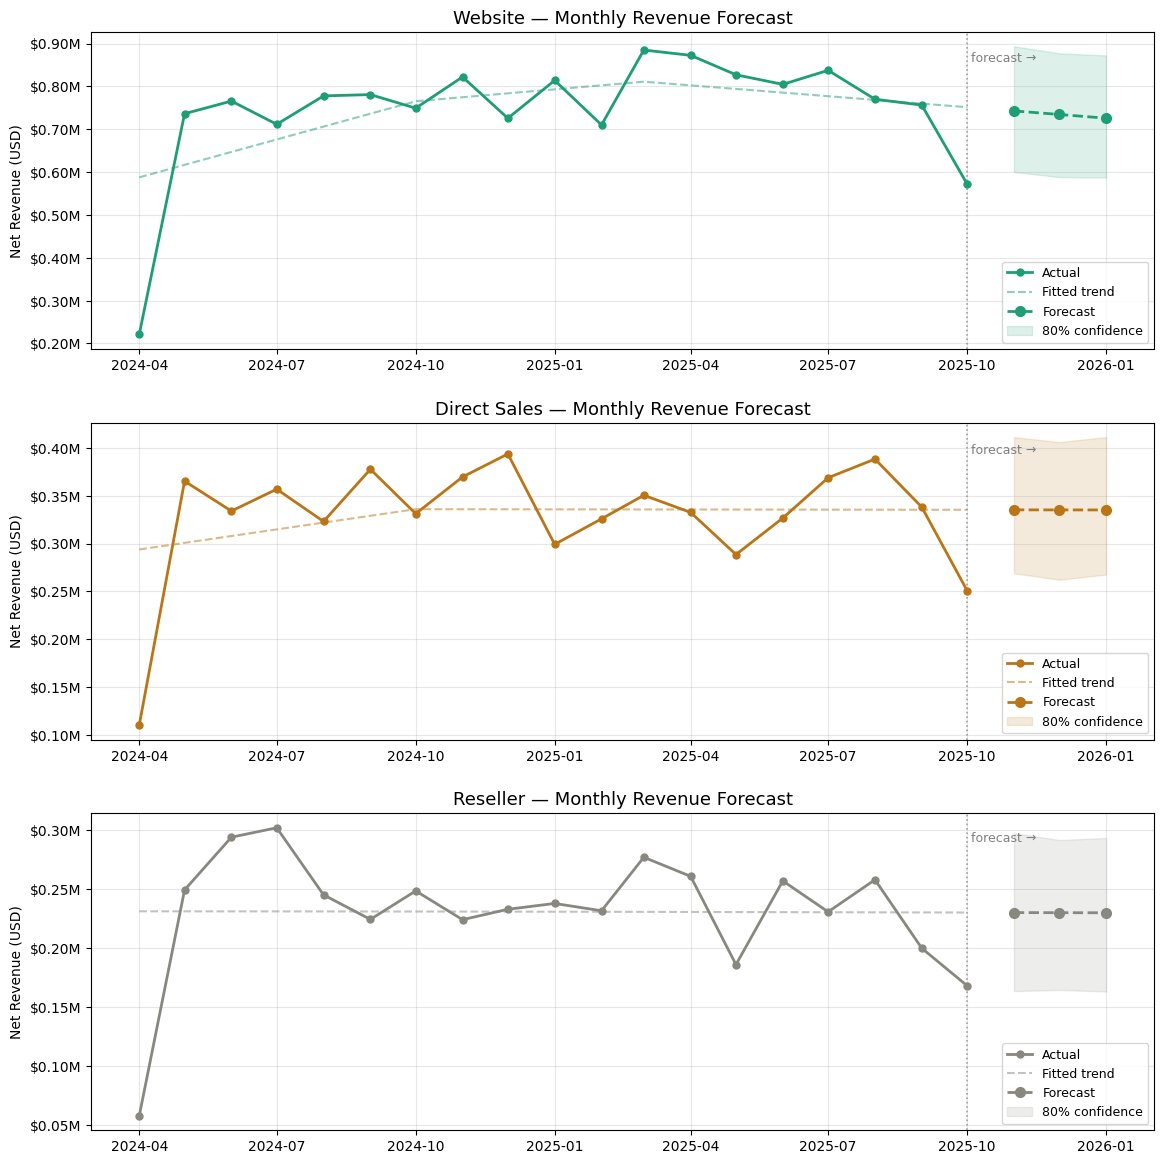

In [57]:
# ── PLOT: actuals + forecast + confidence band ────────────────────────────
fig, axes = plt.subplots(len(top_channels), 1, figsize=(12, 4 * len(top_channels)))
if len(top_channels) == 1:
    axes = [axes]

colors = {'Website': '#1D9E75', 'Marketplace': '#378ADD', 'Direct Sales': '#BA7517',
          'Affiliate': '#E24B4A', 'Partner': '#7F77DD', 'Reseller': '#888780'}

for ax, channel in zip(axes, top_channels):
    df_ch, forecast = forecasts[channel]
    color = colors.get(channel, '#444')

    # Split forecast into history period and future period
    cutoff = df_ch['ds'].max()
    hist_fc  = forecast[forecast['ds'] <= cutoff]
    future_fc = forecast[forecast['ds'] > cutoff]

    # Actuals
    ax.plot(df_ch['ds'], df_ch['y'], 'o-', color=color, linewidth=2,
            markersize=5, label='Actual', zorder=3)

    # Historical fit (trend line)
    ax.plot(hist_fc['ds'], hist_fc['yhat'], '--', color=color,
            alpha=0.5, linewidth=1.5, label='Fitted trend')

    # Forecast + confidence band
    ax.plot(future_fc['ds'], future_fc['yhat'], 'o--', color=color,
            linewidth=2, markersize=7, label='Forecast')
    ax.fill_between(future_fc['ds'],
                    future_fc['yhat_lower'], future_fc['yhat_upper'],
                    alpha=0.15, color=color, label='80% confidence')

    # Vertical line at forecast start
    ax.axvline(cutoff, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(cutoff, ax.get_ylim()[1] * 0.95, ' forecast →',
            fontsize=9, color='gray', va='top')

    ax.set_title(f'{channel} — Monthly Revenue Forecast', fontsize=13)
    ax.set_ylabel('Net Revenue (USD)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout(pad=2)
plt.show()

---

## Business Recommendations

**1. Shift 20–30% of Paid Search budget to Affiliate and Website**
Paid Search Enterprise churn = 47.6%. Affiliate Enterprise churn = 16.7%. Website ARPU = $3,558 vs Paid Search ARPU = $1,703. The LTV difference justifies a higher cost-per-acquisition for Affiliate customers. This is the highest-impact budget reallocation available without increasing total spend.

**2. Fix Month 1 onboarding before any new acquisition campaign**
695 signups → 352 retained in Month 1 (50.6%). Improving to 65% = ~220 extra retained customers per monthly cohort. At $3,558 avg ARPU = $783K additional annual revenue per cohort — with zero extra acquisition cost. No campaign produces that ROI.

**3. Measure 90-day LTV of discounted customers before the next discount campaign**
16,614 discounted orders, AOV $619 vs $688 full-price, avg discount 10.7% = ~$1.1M in foregone revenue. If discounted customers have lower 90-day LTV, cap discounts to annual subscription upgrades only and eliminate them from Consumer and one-time segments.

**4. Fix or remove Services/UK via Direct Sales and Support/Philippines via Marketplace**
Services/UK: 16.67% refund rate, $4,150 lost. Support/Philippines: 15.38%, $5,727 lost. Adobe Firefly/Canada/Reseller: 18.18%, $5,674 lost. Review product listing and support language for each. If unfixable in one sprint — remove from that channel. The refund cost exceeds the acquisition value.

**5. Build proactive retention for Cluster 3 customers**
Cluster 3 = $15K–$38K revenue per customer. Assign dedicated account management and renewal outreach 60 days before contract end. Do not wait for churn signals — in an annual subscription model, the decision to leave is made months before it shows in data.

**6. Track three leading indicators monthly — not just total revenue**
Total revenue in an 88% annual subscription business hides problems for 6–12 months. Track instead:
- Renewal-to-new revenue ratio (falling = base eroding)
- Month 1 retention rate (falling = acquisition quality or onboarding broke)
- Cluster 3 customer count (falling = top revenue at risk before it shows in total revenue)
